# 投资组合市场风险估计 — 蒙特卡洛模拟

本项目运用蒙特卡洛模拟方法，量化评估A股宽基指数投资组合的市场风险。本次研究选取沪深300、中证500、创业板、科创50共4只ETF作为投资标的。

项目通过生成海量未来收益情景，测算投资组合的潜在亏损。基于模拟得到的损失分布，计算风险价值（VaR）与预期短缺（ES）两大核心风险指标。

本项目验证了模拟量化方法在金融风险管理中的实际用途，能够有效评估市场不确定性与尾部极端下行风险。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
data = pd.read_csv("A股投资组合.csv", index_col="date", parse_dates=True, encoding="gbk")
data.head()

,沪深300ETF,中证500ETF,创业板ETF,科创50ETF\n
date,,,,
2020-11-16,5.362,1.973,2.620,1.465
2020-11-17,5.353,1.960,2.572,1.436
2020-11-18,5.346,1.958,2.534,1.424
2020-11-19,5.388,1.969,2.556,1.438
2020-11-20,5.403,1.986,2.576,1.435


## 数据准备

根据沪深 300、中证 500、创业板、科创 50 四只 ETF 的历史收盘价格，计算资产日对数收益率，构建等权重配置的指数投资组合。

整理完成的组合历史收益率序列，将作为后续风险参数估算、蒙特卡洛情景模拟的数据基础。

In [3]:
returns = np.log(data / data.shift(1)).dropna()

weights = np.array([0.25, 0.25, 0.25, 0.25])
portfolio_returns = returns.dot(weights)

portfolio_returns.head()

date
2020-11-17   -0.011694
2020-11-18   -0.006401
2020-11-19    0.007964
2020-11-20    0.004271
2020-11-23    0.003920
dtype: float64

## 参数估计

基于投资组合历史日收益率序列，拟合蒙特卡洛模拟所需正态分布核心参数。

计算组合日均预期收益率μ、日收益波动标准差σ，确定指数组合的收益分布特征。

In [4]:
mu = portfolio_returns.mean()
sigma = portfolio_returns.std()

print("Estimated mean:", mu)
print("Estimated volatility:", sigma)

Estimated mean: 0.00014001803668095756
Estimated volatility: 0.0139745555335941


## 蒙特卡洛模拟

基于已估计的组合收益率均值与波动率，模拟生成大量未来投资组合可能出现的收益结果。

以此构建完整的未来收益模拟分布，用于后续金融风险指标的量化计算与评估。

In [5]:
n_simulations = 10000

simulated_returns = np.random.normal(mu, sigma, n_simulations)

simulated_returns[:10]

array([ 0.00242555, -0.00210251, -0.00459169, -0.00124419,  0.00768552,
        0.0072209 , -0.01275277, -0.01171848, -0.00402248, -0.00735063])

## 模拟损失分布

我们对模拟收益率取相反数，将收益序列转换为投资组合亏损序列。

依托整理完成的模拟损失分布，即可后续测算风险价值（VaR）与预期短缺（ES）两项核心金融尾部风险指标。

In [6]:
simulated_losses = -simulated_returns

simulated_losses[:10]

array([-0.00242555,  0.00210251,  0.00459169,  0.00124419, -0.00768552,
       -0.0072209 ,  0.01275277,  0.01171848,  0.00402248,  0.00735063])

## 尾部风险指标（VaR & ES）计算
根据模拟得到的组合损失分布，分别测算95%、99%置信水平下的风险价值VaR，以及对应极端尾部预期亏损ES。

In [7]:
mc_var_95 = np.quantile(simulated_losses, 0.95)
mc_var_99 = np.quantile(simulated_losses, 0.99)

mc_es_95 = simulated_losses[simulated_losses >= mc_var_95].mean()
mc_es_99 = simulated_losses[simulated_losses >= mc_var_99].mean()

print("Monte Carlo VaR 95%:", mc_var_95)
print("Monte Carlo VaR 99%:", mc_var_99)
print("Monte Carlo ES 95%:", mc_es_95)
print("Monte Carlo ES 99%:", mc_es_99)

Monte Carlo VaR 95%: 0.023086375121223003
Monte Carlo VaR 99%: 0.03306578043620307
Monte Carlo ES 95%: 0.029281802850681656
Monte Carlo ES 99%: 0.03836084610024645


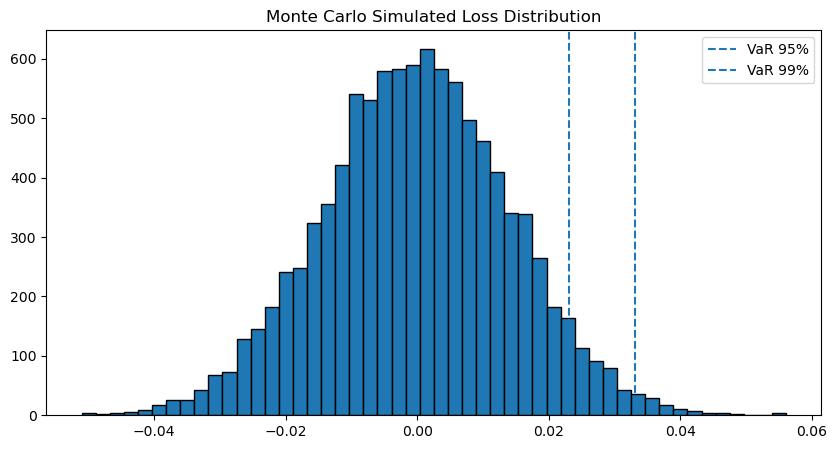

In [8]:
plt.figure(figsize=(10,5))
plt.hist(simulated_losses, bins=50, edgecolor="black")
plt.axvline(mc_var_95, linestyle="--", label="VaR 95%")
plt.axvline(mc_var_99, linestyle="--", label="VaR 99%")
plt.title("Monte Carlo Simulated Loss Distribution")
plt.legend()
plt.show()

## 与历史模拟法对比

为更直观分析模拟建模效果，将蒙特卡洛风险测算结果，与基于历史真实收益序列计算的风险估计结果进行对比。

以此区分模型驱动法与历史数据驱动法两种风控思路的测算差异。

In [9]:
hist_var_95 = -np.quantile(portfolio_returns, 0.05)
hist_var_99 = -np.quantile(portfolio_returns, 0.01)

print("Historical VaR 95%:", hist_var_95)
print("Historical VaR 99%:", hist_var_99)

print("Monte Carlo VaR 95%:", mc_var_95)
print("Monte Carlo VaR 99%:", mc_var_99)

Historical VaR 95%: 0.020203343034250018
Historical VaR 99%: 0.03240958820644497
Monte Carlo VaR 95%: 0.023086375121223003
Monte Carlo VaR 99%: 0.03306578043620307


## 项目总结

本项目选取沪深 300、中证 500、创业板、科创 50 四只 A 股宽基 ETF 构建等权重投资组合，分别通过历史模拟法与蒙特卡洛模拟法，测算 95%、99% 双置信水平下的组合日度市场风险价值 VaR。

从测算结果可以看出：95% 常规置信水平下，蒙特卡洛模拟风险值略高于历史真实行情测算结果；99% 极端尾部置信水平下，蒙特卡洛风险值反而低于历史模拟结果，两种方法呈现明显差异化结论。

该差异核心来源于底层模型逻辑与 A 股市场收益特征：

蒙特卡洛模拟基于正态分布假设生成收益情景，但 A 股指数收益率具备典型尖峰厚尾特性：日常涨跌波动更集中，极端暴跌、暴涨的尾部风险远多于正态分布预期。正态模型平滑弱化了 A 股黑天鹅极端下行风险，因此高置信水平下严重低估尾部亏损。

历史模拟属于纯数据驱动方法，无额外模型假设，完全沿用 A 股真实历史涨跌与极端行情数据，对尾部极端风险的刻画更贴合国内市场实际情况。
组合内创业板、科创 50 等高波动标的，进一步放大了收益非正态特征，拉大了两种算法的结果差距。

综上，两种风控模型在 A 股投资风险管理中各有优劣、互为补充。历史模拟法保守严谨，更贴合 A 股真实尾部极端风险；蒙特卡洛情景模拟灵活性更强，可前瞻性推演未知市场波动，但结果高度依赖收益分布假设合理性。实际投资风控中，需结合两类方法交叉验证，才能全面、合理地评估权益组合真实市场不确定性与下行风险。

## 补充：T分布蒙特卡洛模拟（修正A股尖峰厚尾特征）
针对A股收益率尖峰厚尾的特性，使用t分布进行蒙特卡洛模拟，更贴合市场真实波动特征。

In [16]:
from scipy.stats import t
df_fit, loc_fit, scale_fit = t.fit(portfolio_returns)

print("从历史数据拟合出的最优自由度 df =", round(df_fit))
print("精确df值 =", df_fit)

从历史数据拟合出的最优自由度 df = 4
精确df值 = 3.865492479358191


In [32]:
n_simulations = 10000
simulated_returns_t = mu + sigma * np.random.standard_t(df=df_fit, size=n_simulations)
simulated_returns_t[:10]

array([ 0.0137222 , -0.00695369, -0.00615307,  0.00254191, -0.00047429,
       -0.01993404,  0.00042916, -0.00502577,  0.00428398, -0.00808175])

In [33]:
simulated_losses_t = -simulated_returns_t
simulated_losses_t[:10]

array([-0.0137222 ,  0.00695369,  0.00615307, -0.00254191,  0.00047429,
        0.01993404, -0.00042916,  0.00502577, -0.00428398,  0.00808175])

In [34]:
mc_var_95_t = np.quantile(simulated_losses_t, 0.95)
mc_var_99_t = np.quantile(simulated_losses_t, 0.99)

mc_es_95_t = simulated_losses_t[simulated_losses_t >= mc_var_95_t].mean()
mc_es_99_t = simulated_losses_t[simulated_losses_t >= mc_var_99_t].mean()

print("T_Monte Carlo 95% VaR：", mc_var_95_t)
print("T_Monte Carlo 99% VaR：", mc_var_99_t)
print("T_Monte Carlo 95% ES：", mc_es_95_t)
print("T_Monte Carlo 99% ES：", mc_es_99_t)

T_Monte Carlo 95% VaR： 0.030467446053019324
T_Monte Carlo 99% VaR： 0.054200486447784225
T_Monte Carlo 95% ES： 0.04606878934073572
T_Monte Carlo 99% ES： 0.07370401871361473


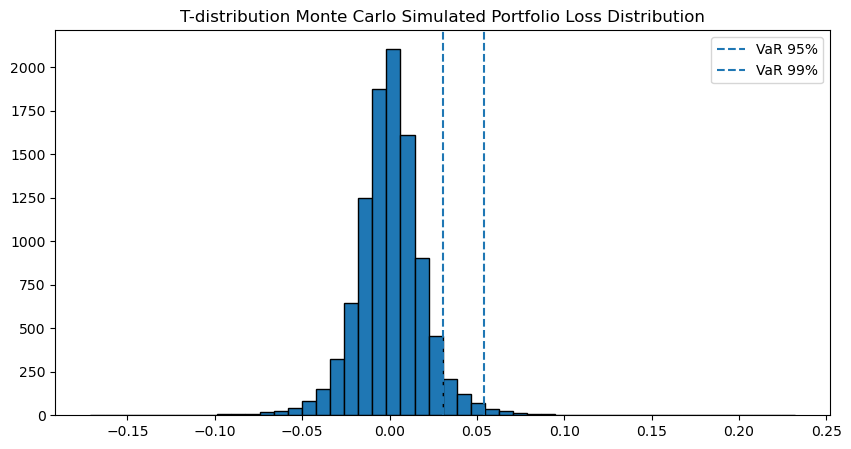

In [35]:
plt.figure(figsize=(10,5))
plt.hist(simulated_losses_t, bins=50, edgecolor="black")
plt.axvline(mc_var_95_t, linestyle="--", label="VaR 95%")
plt.axvline(mc_var_99_t, linestyle="--", label="VaR 99%")
plt.title("T-distribution Monte Carlo Simulated Portfolio Loss Distribution")
plt.legend()
plt.show()

In [36]:
print("Historical VaR 95%:", hist_var_95)
print("Historical VaR 99%:", hist_var_99)

print("Monte Carlo VaR 95%:", mc_var_95)
print("Monte Carlo VaR 99%:", mc_var_99)

print("T_Monte Carlo 95% VaR：", mc_var_95_t)
print("T_Monte Carlo 99% VaR：", mc_var_99_t)

Historical VaR 95%: 0.020203343034250018
Historical VaR 99%: 0.03240958820644497
Monte Carlo VaR 95%: 0.023086375121223003
Monte Carlo VaR 99%: 0.03306578043620307
T_Monte Carlo 95% VaR： 0.030467446053019324
T_Monte Carlo 99% VaR： 0.054200486447784225


## 总结
使用t分布模拟情况反而比正态分布效果更差，原因之一可能是A股上涨温和，但暴跌时很剧烈，并不对称